In [2]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time
import SoftImpute
import TabCSDI


In [3]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [4]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from SoftImpute import softimpute, cv_softimpute
from TabCSDI import TabCSDIImputer


In [5]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [6]:
import pandas as pd
import os

# Update with your actual path to the folder
folder_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Data\gas+sensor+array+drift+dataset+at+different+concentrations"

combined_rows = []

# Loop over batch1 to batch10
for i in range(1, 11):
    file_path = os.path.join(folder_path, f"batch{i}.dat")

    with open(file_path, 'r') as file:
        for line in file:
            if ';' not in line:
                continue  # skip malformed lines
            try:
                _, features_part = line.strip().split(';')
                features = features_part.strip().split()
                values = [float(f.split(":")[1]) for f in features if ":" in f]
                combined_rows.append(values)
            except Exception as e:
                print(f"Skipping line due to error: {e}")
                continue

# Convert to DataFrame
gas_df = pd.DataFrame(combined_rows)

#adding coloumn names
column_names = [f"Sensor_{i}" for i in range(1, 129)]
gas_df.columns = column_names


In [7]:
gas_df.head()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,Sensor_10,...,Sensor_119,Sensor_120,Sensor_121,Sensor_122,Sensor_123,Sensor_124,Sensor_125,Sensor_126,Sensor_127,Sensor_128
0,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,38379.0664,2.851173,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,51975.5899,3.480866,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [8]:
X_full = gas_df.copy()

In [9]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 128 entries, Sensor_1 to Sensor_128
dtypes: float64(128)
memory usage: 13.6 MB
None


MinMax Scalling

In [10]:
#scaler = MinMaxScaler() #data [0,1]
#X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [11]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [12]:
print(GroundTruth)

       Sensor_1  Sensor_2  Sensor_3  Sensor_4  Sensor_5  Sensor_6  Sensor_7  \
0     -0.498823 -0.353696 -0.599967 -0.640209 -0.508537  0.504313  0.519048   
1     -0.344104 -0.304448 -0.427355 -0.491356 -0.504699  0.348537  0.402966   
2     -0.119290 -0.236096 -0.269090 -0.330763 -0.400975  0.117085  0.231118   
3     -0.108947 -0.236318 -0.046722 -0.099488  0.341659  0.102857  0.221204   
4      0.110479 -0.181176 -0.084136 -0.121640 -0.242369 -0.151210  0.038570   
...         ...       ...       ...       ...       ...       ...       ...   
13905 -0.307916 -0.246847 -0.485160 -0.549709 -0.458386  0.414751  0.421862   
13906 -0.143795 -0.249012 -0.151498 -0.207163 -0.155137  0.077420  0.166321   
13907  1.901950  0.664126  1.848079  1.812697  1.423620 -1.601135 -1.559541   
13908 -0.306050 -0.301808 -0.353361 -0.399921 -0.338603  0.244922  0.297209   
13909  2.581928  0.929003  2.725796  2.775733  2.373641 -2.141793 -2.569631   

       Sensor_8  Sensor_9  Sensor_10  ...  Sensor_1

Converting GroundTruth to tensor

In [13]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [14]:
GroundTruth.nunique()

Sensor_1      13904
Sensor_2      13890
Sensor_3      13904
Sensor_4      13905
Sensor_5      13904
              ...  
Sensor_124    13907
Sensor_125    13903
Sensor_126    13898
Sensor_127    13905
Sensor_128    13907
Length: 128, dtype: int64

Dependecies for MAR & MNAR

In [15]:
import numpy as np

# Assign column names if not done already
X.columns = [f"Sensor_{i}" for i in range(1, 129)]
columns = X.columns.tolist()

# Select 115 columns (~90%) to inject MAR missingness
np.random.seed(42)
target_cols = np.random.choice(columns, size=120, replace=False)

# Create MAR dependencies
dependencies_mar = {}

for target_col in target_cols:
    # Select a different column as influencer
    influencer_col = np.random.choice([col for col in columns if col != target_col])
    
    # Compute threshold (mean) of the influencer column
    threshold = X[influencer_col].mean()
    
    # Define MAR dependency rule
    dependencies_mar[target_col] = {
        "influencers": [influencer_col],
        "condition": lambda row: True,
        "probability": lambda row, infl=influencer_col, thresh=threshold: 0.5 if row[infl] > thresh else 0.1
    }

#Check how many columns will have missingness
print("Number of columns with MAR missingness:", len(dependencies_mar))


Number of columns with MAR missingness: 120


In [16]:
import numpy as np

# Make sure columns are named Sensor_1 to Sensor_128
X.columns = [f"Sensor_{i}" for i in range(1, 129)]
columns = X.columns.tolist()

# Select 115 features (~90%) for MNAR missingness
np.random.seed(42)
target_cols_mnar = np.random.choice(columns, size=120, replace=False)

# Create MNAR dependencies
dependencies_mnar = {}

for target_col in target_cols_mnar:
    # Compute threshold from the column itself
    threshold = X[target_col].mean()  # or use median
    
    dependencies_mnar[target_col] = {
        "condition": lambda row: True,
        "probability": lambda row, col=target_col, thresh=threshold: 0.5 if row[col] > thresh else 0.1
    }

#Check number of affected columns
print("Number of columns with MNAR missingness:", len(dependencies_mnar))


Number of columns with MNAR missingness: 120


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [18]:
import numpy as np
import pandas as pd
import torch
import time
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error


missing_rates = [30]  # 10% to 90% missing
rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = []
result_mae = []

for missing_rate in missing_rates:

    # generating missing values
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    # missing mask
    missing_mask = miss_mcar.isna()

    # ===================== OT =====================
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)

        # per-run MAE
        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_OT[missing_mask.values]
        )
        result_mae.append({"Algorithm": "OT-Impute", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    # ===================== MICE =====================
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        imputed_runs_mice.append(X_imputed_mice)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_mice[missing_mask.values]
        )
        result_mae.append({"Algorithm": "MICE", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== SoftImpute =====================
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mcar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            soft_imp[missing_mask.values]
        )
        result_mae.append({"Algorithm": "SoftImpute", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE =====================
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                               hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)
        imputed_runs_miwae.append(X_imputed_miwae)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_miwae[missing_mask.values]
        )
        result_mae.append({"Algorithm": "MIWAE", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN =====================
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_gain[missing_mask.values]
        )
        result_mae.append({"Algorithm": "GAIN", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE-S =====================
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    imputed_runs_miwaes = []
   
    print(f"Run {i+1}...")
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                              hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=20)
        

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({"Algorithm": "MIWAE-S", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

   
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN-S =====================
    print("GAIN-S")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    _ = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
  

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
        )
    result_mae.append({"Algorithm": "GAIN-S", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

   
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE-U =====================
    print("MIWAE-U")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                              hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
       

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
        )
    result_mae.append({"Algorithm": "MIWAE-U", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN-U =====================
    print("GAIN-U")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
       

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
        )
    result_mae.append({"Algorithm": "GAIN-U", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

# Save MAE (per run) and aggregated results
results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...


KeyboardInterrupt: 

In [19]:
  # ---------------------------
    # MIWAE-S (posterior samples; per-run MAE)
    # ---------------------------
print("MIWAE-S")
t_method_start = time.perf_counter()
    
miwaes = MIWAEImputer(
            input_dim=miss_mcar.shape[1],
            latent_dim=16,
            hidden_dims=[256, 128],
            K=10,
            epochs=2500
        )
mean_miwaes, std_miwaes = miwaes.fit_transform_std(
            miss_mcar, return_std=True, inference_K=SAMPLES_S
        )

mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      mean_miwaes[missing_mask.values])
result_mae.append({"Algorithm":"MIWAE-S","MissingRate":missing_rate,"Run":i+1,"MAE":mae_run})

for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                           mean_miwaes[missing_mask.values].flatten(),
                           std_miwaes[missing_mask.values].flatten()):
        results_mcar.append({"Algorithm":"MIWAE-S","MissingRate":missing_rate,
                                 "Time":time.perf_counter() - t_method_start,
                                 "TrueValue":t,"ImputedMean":m,"ImputedStd":s})

    # ---------------------------
    # GAIN-S (train once, sample per run; per-run MAE)
    # ---------------------------
print("GAIN-S (train once, then sample)")
imputer_gains = GAINImputer(epochs=2200, batch_size=1024)
_ = imputer_gains.fit_transform(X_missing_tensor)  # train once

t_method_start = time.perf_counter()
   
mean_gains, std_gains = imputer_gains.sample(num_samples=SAMPLES_S)

mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      mean_gains[missing_mask.values])
result_mae.append({"Algorithm":"GAIN-S","MissingRate":missing_rate,"Run":i+1,"MAE":mae_run})

for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                           mean_gains[missing_mask.values].flatten(),
                           std_gains[missing_mask.values].flatten()):
            results_mcar.append({"Algorithm":"GAIN-S","MissingRate":missing_rate,
                                 "Time":time.perf_counter() - t_method_start,
                                 "TrueValue":t,"ImputedMean":m,"ImputedStd":s})

    # ---------------------------
    # MIWAE-U (single posterior draw per missing; per-run MAE)
    # ---------------------------
print("MIWAE-U")
t_method_start = time.perf_counter()
  
miwaeu = MIWAEImputer(
            input_dim=miss_mcar.shape[1],
            latent_dim=16,
            hidden_dims=[256, 128],
            K=5,
            epochs=2500
        )
mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(
            miss_mcar, return_std=True, inference_K=1
        )

mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      mean_miwaeu[missing_mask.values])
result_mae.append({"Algorithm":"MIWAE-U","MissingRate":missing_rate,"Run":i+1,"MAE":mae_run})

for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                           mean_miwaeu[missing_mask.values].flatten(),
                           std_miwaeu[missing_mask.values].flatten()):
            results_mcar.append({"Algorithm":"MIWAE-U","MissingRate":missing_rate,
                                 "Time":time.perf_counter() - t_method_start,
                                 "TrueValue":t,"ImputedMean":m,"ImputedStd":s})

    # ---------------------------
    # GAIN-U (uncertainty head; per-run MAE)
    # ---------------------------
print("GAIN-U")
t_method_start = time.perf_counter()
   
imputer_gainu = GAINU(epochs=2200, batch_size=1024)  # tuned
mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)

mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      mean_gainu[missing_mask.values])
result_mae.append({"Algorithm":"GAIN-U","MissingRate":missing_rate,"Run":i+1,"MAE":mae_run})

for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                           mean_gainu[missing_mask.values].flatten(),
                           std_gainu[missing_mask.values].flatten()):
            results_mcar.append({"Algorithm":"GAIN-U","MissingRate":missing_rate,
                                 "Time":time.perf_counter() - t_method_start,
                                 "TrueValue":t,"ImputedMean":m,"ImputedStd":s})

# Save MAE-per-run and per-cell results
results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_allMethod_results_with_all_missing_values.csv", index=False)


MIWAE-S
GAIN-S (train once, then sample)
MIWAE-U
GAIN-U


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# Assuming already defined:
# Inject_Missing_Values, OTimputer, MIWAEImputer, GAINImputer, TabCSDIImputer
# GroundTruth (pandas DataFrame aligned with X), X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute", "MIWAE", "GAIN", "TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation (tuned for Gas Sensor) ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=40, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)

            elif algo == "MIWAE":
                imputer = MIWAEImputer(
                    input_dim=X_missing.shape[1],
                    latent_dim=16,
                    hidden_dims=[256, 128],
                    K=10,
                    epochs=2500
                )
                imputed = imputer.fit_transform(X_missing)

            elif algo == "GAIN":
                imputer = GAINImputer(
                    epochs=2200,
                    batch_size=1024
                )
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mcar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=20)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute(missng_soft, lbda)[1]


            # Add this run to the stack
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results (this run) ===
            for t, v, m, s in zip(
                GroundTruth.values[missing_mask.values].flatten(),
                imputed[missing_mask.values].flatten(),
                imputed_mean[missing_mask.values].flatten(),
                imputed_std[missing_mask.values].flatten()
            ):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_results_progressive_multiiple_run.csv",
    index=False
)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mcar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
       
    missing_mask = miss_mcar.isna()
   
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(
                input_dim=miss_mcar.shape[1],
                latent_dim=16,                # was 10
                hidden_dims=[256, 128],       # was [64, 64]
                K=10,
                epochs=2500                   # keep for stability
            )
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(
                epochs=2200,      # was 2500
                batch_size=1024   # was 512
            )
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(
                    epochs=320,          # was 300
                    nsamples=3,          # was 2
                    num_steps=1000,      # keep
                    timeemb=96, featureemb=96,   # was 64,64
                    channels=40, layers=3, nheads=2,
                    seed=None
                )
            tabS.fit(miss_mcar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=20)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_results_sample_runs.csv", index=False)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


## MAR

In [23]:
import numpy as np
import pandas as pd
import torch
import time
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error



missing_rates = [30]  # 10% to 90% missing
rng = np.random.default_rng(42)

# Create nested results dictionary
results_mar = []
result_mae = []

for missing_rate in missing_rates:

    # generating missing values
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X, missing_rate=missing_rate, dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    # missing mask
    missing_mask = miss_mar.isna()

    # ===================== OT =====================
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)

        # per-run MAE
        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_OT[missing_mask.values]
        )
        result_mae.append({"Algorithm": "OT-Impute", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    # ===================== MICE =====================
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        imputed_runs_mice.append(X_imputed_mice)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_mice[missing_mask.values]
        )
        result_mae.append({"Algorithm": "MICE", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== SoftImpute =====================
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            soft_imp[missing_mask.values]
        )
        result_mae.append({"Algorithm": "SoftImpute", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE =====================
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                               hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mar)
        imputed_runs_miwae.append(X_imputed_miwae)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_miwae[missing_mask.values]
        )
        result_mae.append({"Algorithm": "MIWAE", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN =====================
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_gain[missing_mask.values]
        )
        result_mae.append({"Algorithm": "GAIN", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE-S =====================
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    imputed_runs_miwaes = []
   
    print(f"Run {i+1}...")
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                              hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)
        

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({"Algorithm": "MIWAE-S", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

   
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN-S =====================
    print("GAIN-S")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    _ = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
  

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
        )
    result_mae.append({"Algorithm": "GAIN-S", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

   
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE-U =====================
    print("MIWAE-U")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                              hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
       

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
        )
    result_mae.append({"Algorithm": "MIWAE-U", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN-U =====================
    print("GAIN-U")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
       

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
        )
    result_mae.append({"Algorithm": "GAIN-U", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

# Save MAE (per run) and aggregated results
results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
Run 5...
GAIN-S
Run 5...
MIWAE-U
Run 5...
GAIN-U
Run 5...


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate, dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=256)  # matched
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=40, sample_posterior=True, random_state=None)  # matched
                imputed = imputer.fit_transform(X_missing)

            elif algo == "MIWAE":
                imputer = MIWAEImputer(
                    input_dim=X_missing.shape[1],
                    latent_dim=20,
                    hidden_dims=[256, 128, 64],
                    K=15,
                    epochs=2200
                )  # matched
                imputed = imputer.fit_transform(X_missing)

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2200, batch_size=1024)  # matched
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)  # matched
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute(missng_soft, lbda)[1]

         

            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mar = []
runs=3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
       
    missing_mask = miss_mar.isna()
   
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)  # (left as-is)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(
                input_dim=miss_mar.shape[1],
                latent_dim=32,                # was 10
                hidden_dims=[512, 256, 128],  # was [64, 64]
                K=20,                         # was 10
                epochs=3000                   # was 2500
            )
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(
                epochs=3000,     # was 2500
                batch_size=2048  # was 512
            )
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(
                epochs=500,          # was 300
                nsamples=2,          # keep
                num_steps=1500,      # was 1000
                timeemb=128,         # was 64
                featureemb=128,      # was 64
                channels=64,         # was 32
                layers=4,            # was 3
                nheads=4,            # was 2
                seed=None
            )
            tabS.fit(miss_mar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=20)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mar_results_sample_runs.csv", index=False)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


## MNAR

In [24]:
import numpy as np
import pandas as pd
import torch
import time
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, GAINU,
# GroundTruth, X, cv_softimpute, softimpute, dependencies_mnar

missing_rates = [30]  # 10% to 90% missing
rng = np.random.default_rng(42)

# Create nested results dictionary
results_mnar = []
result_mae = []

for missing_rate in missing_rates:

    # generating missing values
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate, dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    # missing mask
    missing_mask = miss_mnar.isna()

    # ===================== OT =====================
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)

        # per-run MAE
        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_OT[missing_mask.values]
        )
        result_mae.append({"Algorithm": "OT-Impute", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    # ===================== MICE =====================
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        imputed_runs_mice.append(X_imputed_mice)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_mice[missing_mask.values]
        )
        result_mae.append({"Algorithm": "MICE", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== SoftImpute =====================
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mnar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            soft_imp[missing_mask.values]
        )
        result_mae.append({"Algorithm": "SoftImpute", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE =====================
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                               hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)
        imputed_runs_miwae.append(X_imputed_miwae)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_miwae[missing_mask.values]
        )
        result_mae.append({"Algorithm": "MIWAE", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN =====================
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

        mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_imputed_gain[missing_mask.values]
        )
        result_mae.append({"Algorithm": "GAIN", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE-S =====================
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    imputed_runs_miwaes = []
   
    print(f"Run {i+1}...")
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                              hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=20)
        

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({"Algorithm": "MIWAE-S", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

   
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN-S =====================
    print("GAIN-S")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    _ = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
  

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
        )
    result_mae.append({"Algorithm": "GAIN-S", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

   
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== MIWAE-U =====================
    print("MIWAE-U")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                              hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)
       

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
        )
    result_mae.append({"Algorithm": "MIWAE-U", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # ===================== GAIN-U =====================
    print("GAIN-U")
    t_method_start = time.perf_counter()
   
    print(f"Run {i+1}...")
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
       

    mae_run = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
        )
    result_mae.append({"Algorithm": "GAIN-U", "MissingRate": missing_rate, "Run": i+1, "MAE": mae_run})

    
    total_time_sec = time.perf_counter() - t_method_start

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

# Save MAE (per run) and aggregated results
results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mnar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
Run 5...
GAIN-S
Run 5...
MIWAE-U
Run 5...
GAIN-U
Run 5...


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=400, batchsize=256)  # tuned
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              
            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=40, sample_posterior=True, random_state=None)  # tuned
                imputed = imputer.fit_transform(X_missing)
             
            elif algo == "MIWAE":
                imputer = MIWAEImputer(
                    input_dim=X_missing.shape[1],
                    latent_dim=20, hidden_dims=[256, 128, 64],  # tuned
                    K=15, epochs=2200                                 # tuned
                )
                imputed = imputer.fit_transform(X_missing)
               
            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2200, batch_size=1024)  # tuned
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mnar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=25)  # tuned
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(
                    epochs=400,             # tuned
                    nsamples=2,             # tuned
                    num_steps=1500,         # tuned
                    timeemb=128, featureemb=128,
                    channels=64, layers=4, nheads=4,
                    seed=42
                )
                imputed = imputer.fit_transform(miss_mnar.to_numpy()) 
                            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mnar_results_progressive_multiiple_run.csv", index=False)



=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Multiple Sample Run

In [ ]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mnar = []
runs=3

for missing_rate in missing_rates:
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
       
    missing_mask = miss_mnar.isna()
   
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(
                input_dim=miss_mnar.shape[1],
                latent_dim=20, hidden_dims=[256, 128, 64],  # tuned for Gas Sensor
                K=15, epochs=2200
            )
            mean_miwae, std_miwae = miwae.fit_transform_std(miss_mnar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            # GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=2200, batch_size=1024)  # tuned for Gas Sensor
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

            print("TabCSDI-S")
            tabS = TabCSDIImputer(
                epochs=400,            # tuned for Gas Sensor
                nsamples=2,
                num_steps=1500,
                timeemb=128, featureemb=128,
                channels=64, layers=4, nheads=4,
                seed=42
            )
            tabS.fit(miss_mnar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=20)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "TabCSDI-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                })

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mnar_results_sample_runs.csv", index=False)


30
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S


In [ ]:
missing_rates = [10,30,50,70,90]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm":"TabCSDI",
            "MissingRate":missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm":"TabCSDI",
        "MissingRate":missing_rate,
        "Run":"mean",
        "MAE":tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
    tabS.fit(miss_mar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({
        "Algorithm":"TabCSDI-S",
        "MissingRate":missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv", index=False)


10
OT-Impute
Run 1...


Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/500] loss=1.100989
[  50/500] loss=0.184097
[ 100/500] loss=0.211925
[ 150/500] loss=0.170242
[ 200/500] loss=0.154724
[ 250/500] loss=0.151135
[ 300/500] loss=0.114514
[ 350/500] loss=0.127875
[ 400/500] loss=0.090711
[ 450/500] loss=0.111045
[ 500/500] loss=0.108972
Run 2...
[   1/500] loss=0.990675
[  50/500] loss=0.195492
[ 100/500] loss=0.153393
[ 150/500] loss=0.156236
[ 200/500] loss=0.117719
[ 250/500] loss=0.127366
[ 300/500] loss=0.130214
[ 350/500] loss=0.121554
[ 400/500] loss=0.107876
[ 450/500] loss=0.140243
[ 500/500] loss=0.090024
Run 3...
[   1/500] loss=1.041684
[  50/500] loss=0.160155
[ 100/500] loss=0.172143
[ 150/500] loss=0.201284
[ 200/500] loss=0.160937
[ 250/500] loss=0

# Visualization

## MCAR

Calibration curve for all algorithms

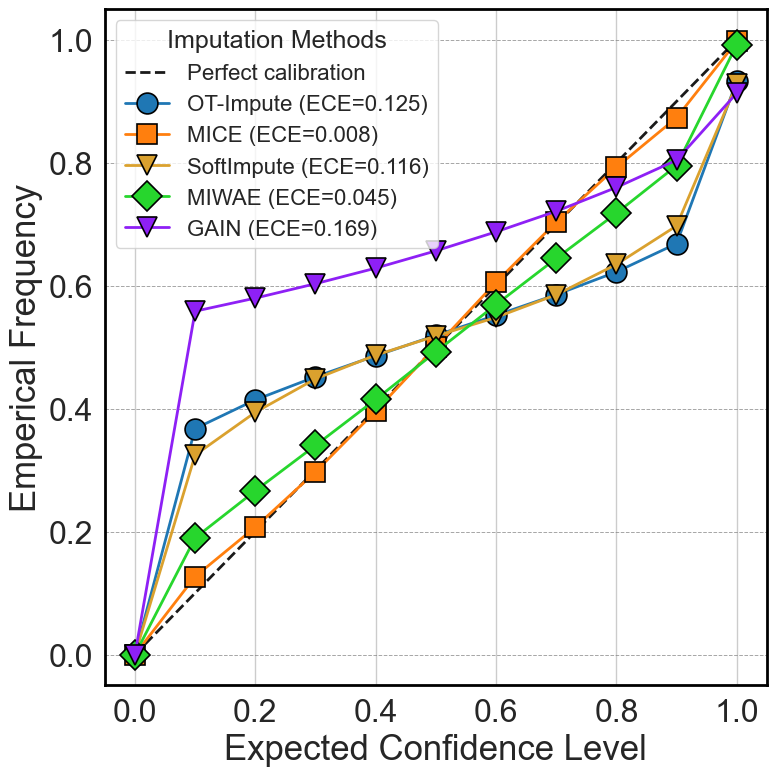

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Gas_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


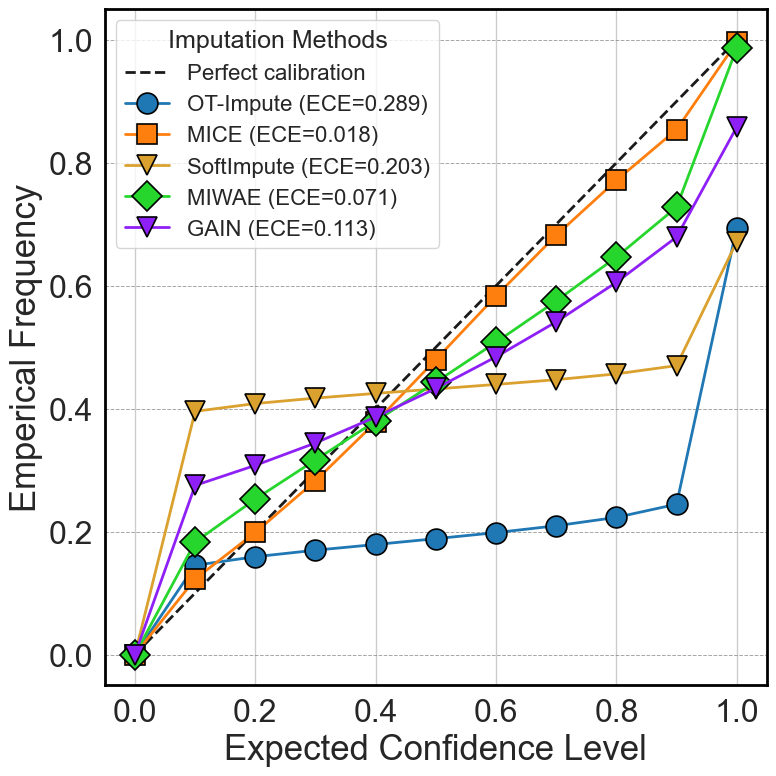

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Gas_MNAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


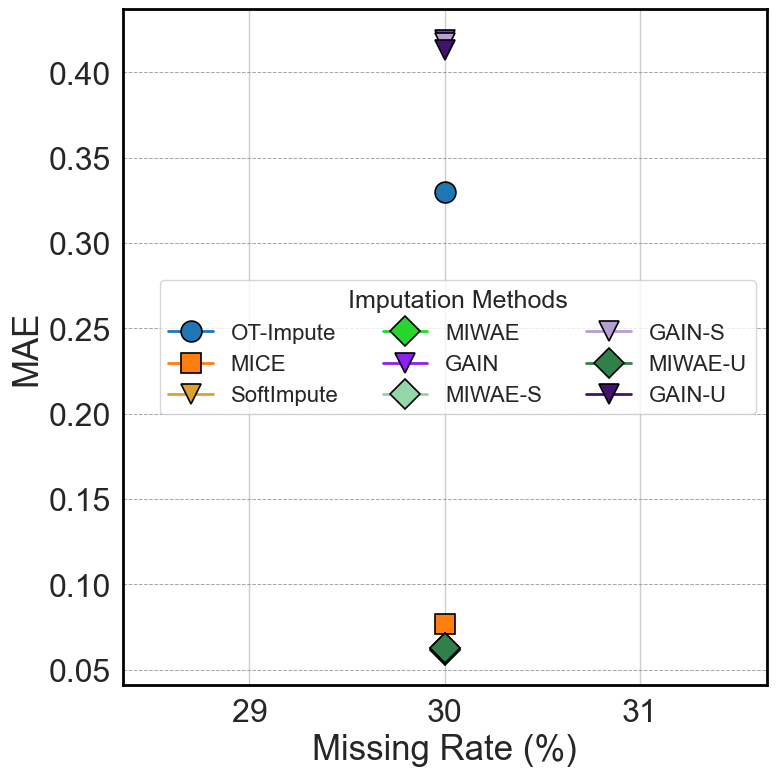

In [22]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Gas_mcar_allMethod_mae.csv"
)

# Keep the same variable name as before
algorithms = df_mae['Algorithm'].unique()
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_mae[df_mae['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())

    # In case there are multiple rows per (algo, rate), average them (same idea as before)
    mae_values = [df_algo[df_algo['MissingRate'] == mr]['MAE'].mean() for mr in missing_rates]

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, mae_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels (same variables)
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
#plt.title("MAE vs Missing Rate for All Algorithms (MAR)", fontsize=28)

# Legend (kept exactly like your ECE code — commented)
plt.legend(ncol=3,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges) — same as your ECE code
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines — same as your ECE code
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Keep the same y-limit line as in your ECE plot
#ax.set_ylim(0.08, 0.30)

# Tick params — same sizes
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Gas_MCAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()
